In [1]:
from HARey_constellation_cards.harey_main import HAReyMain

# Read the constellations file, the HIP catalogue and the object names
harey = HAReyMain(language='ITALIANO', star_colors='helland')

# Set two custom fonts for the plots and the cards names
harey.set_fonts('fonts/CaveatBrush-Regular.ttf', 'fonts/TheWalkyr.ttf')


Loading constellations diagrams....     Done!
Loading star coordinates....     Done!
Computing stars colors...     Done!
Loading custom markers....       Done!
Loading the object names....       Done!


Using the tarot-round format, 2.75x4.75 in, using the template at cardbacks/tarot_round.png
Using Caveat Brush for plot labels
Using The Walkyr for card names


In [2]:
harey.set_limiting_magnitude(7)

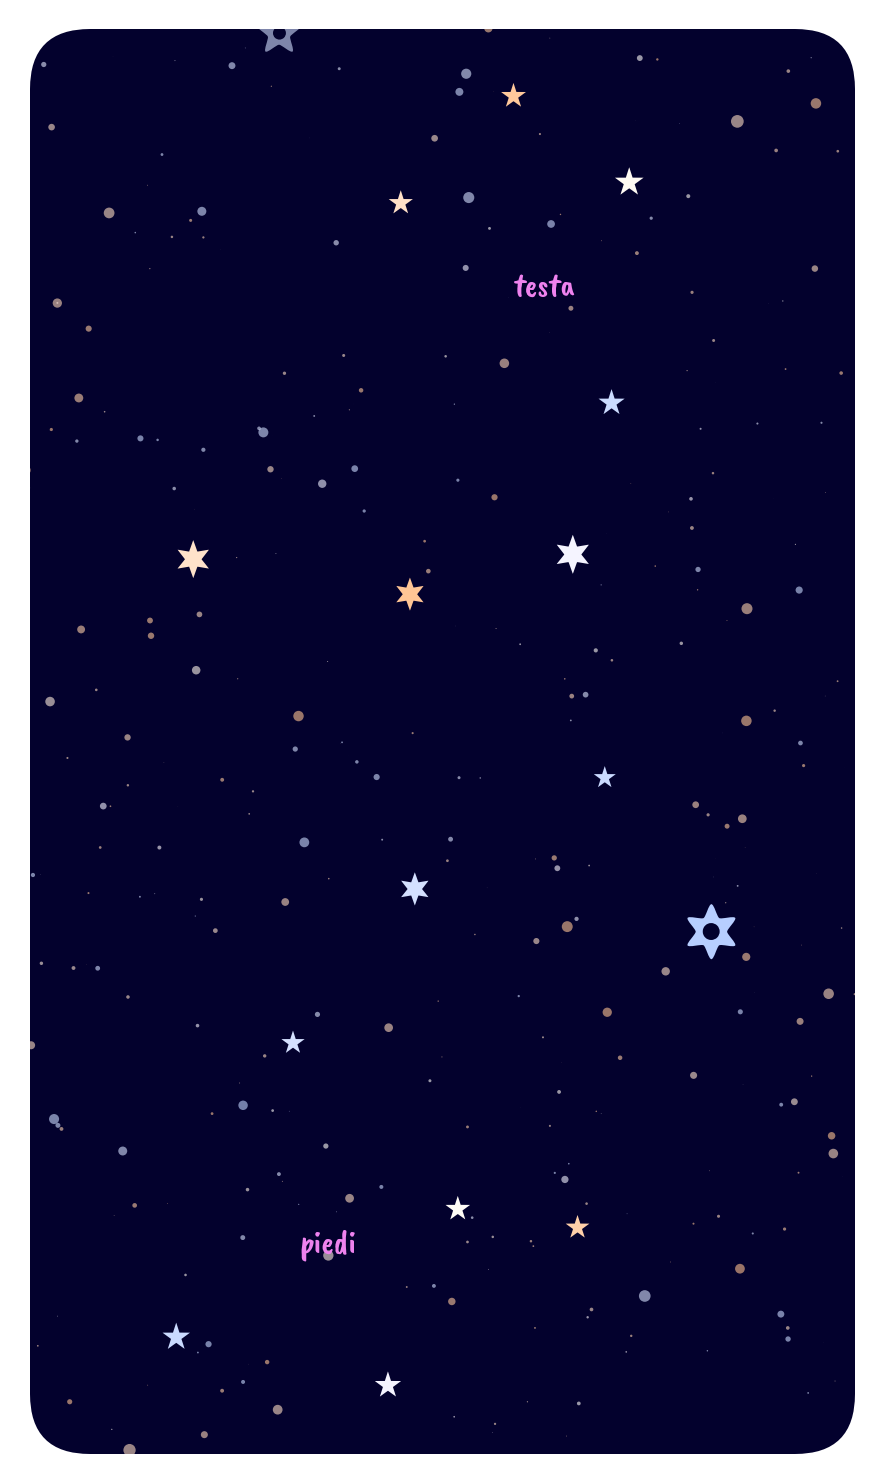

In [3]:
harey.plot_card('Vir', CON_LINES=False, save_name='Ori_square', STAR_COLORS=True, CON_PARTS=True, BEST_AR=True, star_size=250)

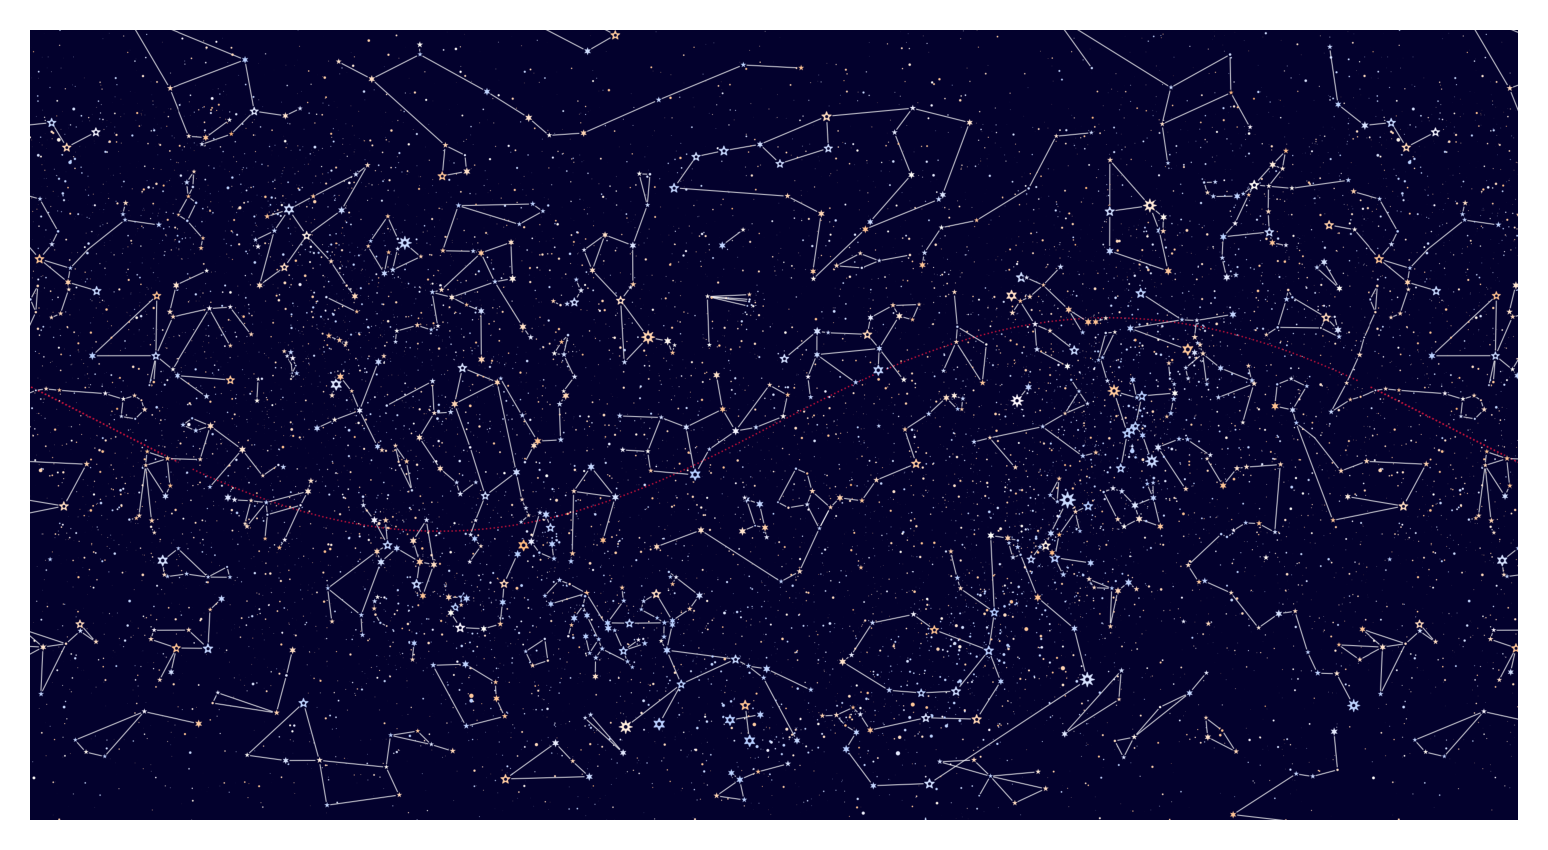

In [4]:
harey.equatorial_map(CON_LINES=True, save_name='map.png', STAR_COLORS=True, GRID=False)

In [65]:
import os
from fpdf import FPDF
folder = 'PROVA4'
bleed = 0.1
filename = 'prova.pdf'
CUTTING_HELPERS = True
harey.set_card_template(format='poker-round')

Using the poker-round format, 2.50x3.50 in, using the template at cardbacks/poker_round.png


In [ ]:
files = os.listdir(folder)
cards = [file for file in files if file.endswith('.png')]
cards.sort() # Sort the cards alphabetically

pdf = FPDF(orientation="P", unit="in", format="A4")

cw, ch = harey.width, harey.height    # Card width, card height
cwb, chb = cw + 2*bleed, ch + 2*bleed  # card width and height with bleed

# If the cards are poker sized and the bleed is 0.1 in or less, print 3x3 cards on paper 
# If instead they are tarot or jumbo, print 2x2 cards 
if cw/ch == 2.5/3.5 and bleed <= 0.1:
    cards_per_page = 9
    grid = 3
else:
    cards_per_page = 4
    grid = 2

# distance from the page margin
margin_w = (pdf.w - grid*cwb)/2
margin_h = (pdf.h - grid*chb)/2

n_cards = len(cards)
n_pages = ((n_cards-1)//(2*cards_per_page) + 1)*2

# Create all the pages and print the separating lines
for i in range(n_pages):
    pdf.add_page()
    for i in range(1, grid):
        pdf.line(0, margin_h + i*chb, pdf.w,  margin_h + i*chb)
        pdf.line(margin_w + i*cwb, 0, margin_w + i*cwb, pdf.h)  

for n, card in enumerate(cards):
    # THe cards are ordered as back_1, back_2, front_1, front_2
    is_back = (n%4)//2 == 0                         # Check if the image is front or back
    index = 2*(n//4) + n%2                          # Index of the card among the fronts or backs
    x = index%grid                                 # x-Position of the image in the grid
    y = (index%cards_per_page)//grid                # y-position

    pdf.page = 2*(index//cards_per_page) + (n%4)//2 + 1

    print(f'n:{n}, is_back:{is_back}, index:{index}, page:{2*(index//cards_per_page) + (n%4)//2 + 1}, x:{x}, y:{y}')
    # When plotting the card fronts, remember to add the bleed
    if is_back:
        pdf.image(f'{folder}/{card}', margin_w + x*cwb + bleed, margin_h + y*chb + bleed, cw, ch)
    else:
        pdf.image(f'{folder}/{card}', margin_w + x*cwb, margin_h + y*chb, cwb, chb)
        
if CUTTING_HELPERS:

    # draw the helpers only on the cardbacks pages (fronts are joined together by the bleed)
    for page in range(1, n_pages+1, 2):
        pdf.page = page       
        pdf.set_draw_color(100)

        for i in range(grid):
            # Left margin lines
            pdf.line(0, margin_h + i*chb + bleed, 0.8*margin_w, margin_h + i*chb + bleed)
            pdf.line(0, margin_h + i*chb + bleed + ch, 0.8*margin_w, margin_h + i*chb + bleed + ch)

            # Right margin lines
            pdf.line(pdf.w, margin_h + i*chb + bleed, pdf.w - 0.8*margin_w, margin_h + i*chb + bleed)
            pdf.line(pdf.w, margin_h + i*chb + bleed + ch, pdf.w - 0.8*margin_w, margin_h + i*chb + bleed + ch)

            # Top margin lines
            pdf.line(margin_w + i*cwb + bleed, 0 , margin_w + i*cwb + bleed, 0.8*margin_h)
            pdf.line(margin_w + i*cwb + bleed + cw, 0 , margin_w + i*cwb + bleed + cw, 0.8*margin_h)

            # Bottom margin lines
            pdf.line(margin_w + i*cwb + bleed, pdf.h , margin_w + i*cwb + bleed, pdf.h - 0.8*margin_h)
            pdf.line(margin_w + i*cwb + bleed + cw, pdf.h , margin_w + i*cwb + bleed + cw, pdf.h - 0.8*margin_h)

        # Internal helpers
        for i in range(grid+1):
            for j in range(grid):
                pdf.line(margin_w + i*cwb - 0.8*bleed, margin_h + j*chb + bleed, margin_w + i*cwb + 0.8*bleed, margin_h + j*chb + bleed)
                pdf.line(margin_w + i*cwb - 0.8*bleed, margin_h + j*chb + bleed + ch, margin_w + i*cwb + 0.8*bleed, margin_h + j*chb + bleed + ch)

        for i in range(grid):
            for j in range(grid+1):
                pdf.line(margin_w + i*cwb + bleed, margin_h + j*chb - 0.8*bleed, margin_w + i*cwb + bleed, margin_h + j*chb + 0.8*bleed)
                pdf.line(margin_w + i*cwb + bleed + cw, margin_h + j*chb - 0.8*bleed, margin_w + i*cwb + bleed + cw, margin_h + j*chb + 0.8*bleed)
            

print(f'\n{n_cards} cards have been printed in the file {filename}\n')
pdf.output(f'{folder}/{filename}')

n:0, is_back:True, index:0, page:1, x:0, y:0
n:1, is_back:True, index:1, page:1, x:1, y:0
n:2, is_back:False, index:0, page:2, x:0, y:0
n:3, is_back:False, index:1, page:2, x:1, y:0
n:4, is_back:True, index:2, page:1, x:2, y:0
n:5, is_back:True, index:3, page:1, x:0, y:1
n:6, is_back:False, index:2, page:2, x:2, y:0
n:7, is_back:False, index:3, page:2, x:0, y:1
n:8, is_back:True, index:4, page:1, x:1, y:1
n:9, is_back:True, index:5, page:1, x:2, y:1
n:10, is_back:False, index:4, page:2, x:1, y:1
n:11, is_back:False, index:5, page:2, x:2, y:1
n:12, is_back:True, index:6, page:1, x:0, y:2
n:13, is_back:True, index:7, page:1, x:1, y:2
n:14, is_back:False, index:6, page:2, x:0, y:2
n:15, is_back:False, index:7, page:2, x:1, y:2
n:16, is_back:True, index:8, page:1, x:2, y:2
n:17, is_back:True, index:9, page:1, x:0, y:0
n:18, is_back:False, index:8, page:4, x:2, y:2
n:19, is_back:False, index:9, page:4, x:0, y:0
n:20, is_back:True, index:10, page:3, x:1, y:0
n:21, is_back:True, index:11, pag

In [67]:
for i in range(40):
    is_back = (i%4)//2==0
    index = 2*(i//4) + i%2
    x = index%3
    y = (index%9)//3
    print(f'i:{i}, is_back: {is_back}, index:{index}, x:{x}, y:{y}')


i:0, is_back: True, index:0, x:0, y:0
i:1, is_back: True, index:1, x:1, y:0
i:2, is_back: False, index:0, x:0, y:0
i:3, is_back: False, index:1, x:1, y:0
i:4, is_back: True, index:2, x:2, y:0
i:5, is_back: True, index:3, x:0, y:1
i:6, is_back: False, index:2, x:2, y:0
i:7, is_back: False, index:3, x:0, y:1
i:8, is_back: True, index:4, x:1, y:1
i:9, is_back: True, index:5, x:2, y:1
i:10, is_back: False, index:4, x:1, y:1
i:11, is_back: False, index:5, x:2, y:1
i:12, is_back: True, index:6, x:0, y:2
i:13, is_back: True, index:7, x:1, y:2
i:14, is_back: False, index:6, x:0, y:2
i:15, is_back: False, index:7, x:1, y:2
i:16, is_back: True, index:8, x:2, y:2
i:17, is_back: True, index:9, x:0, y:0
i:18, is_back: False, index:8, x:2, y:2
i:19, is_back: False, index:9, x:0, y:0
i:20, is_back: True, index:10, x:1, y:0
i:21, is_back: True, index:11, x:2, y:0
i:22, is_back: False, index:10, x:1, y:0
i:23, is_back: False, index:11, x:2, y:0
i:24, is_back: True, index:12, x:0, y:1
i:25, is_back: Tru